# SEIRS-SEI Malaria Model - Yearly Sequential Topic Calibration (lmfit)

Replaces the previous **grid-search** calibration with **lmfit differential evolution**.

The full 2017-2023 period is fitted **one year at a time**. For each year the
parameters are calibrated **by topic in sequence**, fixing the previous topics at
their best values. The year is then simulated with the fully fitted parameters and
its **end-state is carried forward** as the initial condition of the next year.

## Per-year fitting order

1. **IC (2017 only)** - initial conditions: `S_H0_frac`, `E_H0_frac`, `I_M0_ratio`
   (`I_H0` is fixed from the first observed data point; `R_H0` is the residual of N).
2. **Humidity** - `H0`, `k`, `phi` (humidity-dependent mosquito survival).
3. **Human transmission** - `tau_H`, `gamma`, `omega`.
4. **Force of infection** - `b1` (mosquito acquisition), `b2` (human acquisition).
5. **Carrying capacity** - `M_prime` (mosquito habitat carrying capacity).

For 2018+ the IC step is skipped: the initial state is the end-state of the
previous year's simulation. Fitted parameter values are carried from each year to
the next as the starting guesses of the corresponding topic.

**Objective**: time-weighted MSE within each year (exponential weighting, early
months weighted higher - same scheme as the weighted humidity/human notebooks,
applied per year).

**Results**: saved to `lmfit_results.json`.

**Runtime**: a full run of all 7 years takes roughly 30-45 minutes. A quick
test mode (`QUICK = True`) with a tiny DE budget is provided below.

## Step 1 - lmfit availability check

In [3]:
import importlib.util

if importlib.util.find_spec('lmfit') is None:
    print('lmfit is NOT installed in this environment.')
    print('Install it (e.g. with: pip install lmfit), then restart the kernel and re-run from the top.')
else:
    import lmfit
    print('lmfit is available:', lmfit.__version__)

lmfit is available: 1.3.2


## Step 2 - Imports and shared model code

`lmfit_optimization_shared.py` (in this folder) holds all data loading, the ODE
model, the per-year simulator and the lmfit objective builders.

In [5]:
from lmfit_optimization_shared import *
%matplotlib inline
import warnings, json, os, time
import pandas as pd
warnings.filterwarnings('ignore')

Climate data 2017-2023: 2556 days
Cases data 2017-2023: 2556 rows
lmfit version: 1.3.2

2017 direct start (no warm-up): N=8369, M'=334760 (40.00 x N)
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=76994, E_M=5022, I_M=1674


## Step 3 - Configuration

- `QUICK = True`  -> tiny DE budget, just to check the pipeline (~1-2 min).
- `QUICK = False` -> full differential-evolution run for all years (~30-45 min).

`max_nfev` caps the number of model evaluations per topic fit (lmfit ignores
`maxiter` for this method, so the budget is controlled here).

In [7]:
QUICK = True

YEARS = list(range(2017, 2024))

if QUICK:
    DE_SETTINGS = dict(seed=42, popsize=4, max_nfev=80, tol=0.01, polish=False)
else:
    DE_SETTINGS = dict(DEFAULT_DE_SETTINGS)  # popsize=6, max_nfev=300, seed=42

# RESULTS_FILE is already provided by the shared module (points into this folder)
print('QUICK =', QUICK)
print('DE settings:', DE_SETTINGS)
print('Years:', YEARS)
print('Results file:', RESULTS_FILE)

QUICK = True
DE settings: {'seed': 42, 'popsize': 4, 'max_nfev': 80, 'tol': 0.01, 'polish': False}
Years: [2017, 2018, 2019, 2020, 2021, 2022, 2023]
Results file: C:\Users\rapha\Study_on_malaria_dynamics_v2\models\seirs_sei\lmfit_optimization\lmfit_results.json


## Step 4 - Baseline (default parameters, fixed 2017 ICs)

Simulates the full period with the default parameters and the fixed ode_models
initial conditions, to quantify the improvement after calibration.

In [9]:
print('Simulating baseline (default params, fixed 2017 ICs)...')
t0 = time.time()
base_traj, base_mse = run_baseline(YEARS)
print(f'done in {time.time()-t0:.1f}s')
print(f"{'Year':<6}{'Baseline wMSE':>16}")
for y in YEARS:
    print(f'{y:<6}{base_mse[y]:>16,.0f}')

Simulating baseline (default params, fixed 2017 ICs)...
done in 2.6s
Year     Baseline wMSE
2017           869,159
2018           727,384
2019           284,498
2020           334,886
2021           151,968
2022            67,312
2023            89,338


## Step 5 - Yearly sequential topic calibration

Runs lmfit differential evolution for every topic of every year, carrying the
best fitted values forward. If the notebook is interrupted, re-run from the top
with `resume=True` in the cell below to load the saved `lmfit_results.json`.

In [11]:
print('Running yearly sequential topic fitting (lmfit differential_evolution)...')
print('Order per year: [2017 only: IC] -> humidity -> human -> FoI -> M_prime')

t0 = time.time()
results, trajectories = run_yearly_fit(
    years=YEARS,
    de_settings=DE_SETTINGS,
    save_json=True,
    results_file=RESULTS_FILE,
    resume=False,
    verbose=True,
)

elapsed = time.time() - t0
print(f'\nTotal elapsed: {elapsed:.1f}s (~{elapsed/60:.1f} min)')
print(f'Results saved to: {RESULTS_FILE}')

Running yearly sequential topic fitting (lmfit differential_evolution)...
Order per year: [2017 only: IC] -> humidity -> human -> FoI -> M_prime

=== Fitting year 2017 ===
IC: S_H0_frac=0.5108, E_H0_frac=0.0245, I_M0_ratio=0.0061  (chisqr=1.649e+11, nfev=81)
  humidity: H0=29.94, k=0.09358, phi=0.4585  (chisqr=1.34e+11, nfev=81)
  human: tau_H=45.13, gamma=0.003088, omega=0.01703  (chisqr=9.72e+11, nfev=81)
  foi: b1=0.02658, b2=0.03874  (chisqr=2.672e+10, nfev=81)
  m_prime: M_prime=4.27e+05  (chisqr=2.296e+10, nfev=20)
  -> year 2017: weighted MSE = 151528.7924

=== Fitting year 2018 ===
  humidity: H0=39.4, k=0.1064, phi=0.181  (chisqr=1.399e+10, nfev=81)
  human: tau_H=2.174, gamma=0.001983, omega=0.02902  (chisqr=4.194e+10, nfev=81)
  foi: b1=0.00104, b2=0.08628  (chisqr=3.39e+09, nfev=81)
  m_prime: M_prime=4.221e+05  (chisqr=3.394e+09, nfev=15)
  -> year 2018: weighted MSE = 58259.5965

=== Fitting year 2019 ===
  humidity: H0=24.96, k=0.2817, phi=0.4687  (chisqr=1.774e+09, nfev

## Step 6 - Results summary

In [13]:
rows = []
for y in YEARS:
    yr = results[str(y)]
    for topic in ['IC', 'humidity', 'human', 'foi', 'm_prime']:
        if topic in yr:
            entry = {'year': y, 'topic': topic}
            entry.update(yr[topic])
            rows.append(entry)

tbl = pd.DataFrame(rows)
if 'wMSE' in tbl.columns:
    tbl['wMSE'] = tbl['wMSE'].astype(float).round(0)
print('Per-topic fit summary (wMSE = sqrt(chisqr) at that stage):')
print(tbl.to_string(index=False))

print('\nFinal per-year weighted MSE (all topics fitted):')
print(f"{'Year':<6}{'Calibrated':>16}{'Baseline':>16}")
for y in YEARS:
    print(f'{y:<6}{results[str(y)]["weighted_mse"]:>16,.0f}{base_mse[y]:>16,.0f}')

Per-topic fit summary (wMSE = sqrt(chisqr) at that stage):
 year    topic  S_H0_frac  E_H0_frac  I_M0_ratio       chisqr     wMSE  nfev  success        H0        k      phi     tau_H    gamma    omega       b1       b2      M_prime
 2017       IC   0.510816   0.024476    0.006055 1.649477e+11 406138.0    81    False       NaN      NaN      NaN       NaN      NaN      NaN      NaN      NaN          NaN
 2017 humidity        NaN        NaN         NaN 1.339567e+11 366001.0    81    False 29.937247 0.093580 0.458502       NaN      NaN      NaN      NaN      NaN          NaN
 2017    human        NaN        NaN         NaN 9.720498e+11 985926.0    81    False       NaN      NaN      NaN 45.131905 0.003088 0.017031      NaN      NaN          NaN
 2017      foi        NaN        NaN         NaN 2.672451e+10 163476.0    81    False       NaN      NaN      NaN       NaN      NaN      NaN 0.026576 0.038742          NaN
 2017  m_prime        NaN        NaN         NaN 2.296097e+10 151529.0    20

## Step 7 - Visualization: model vs observed

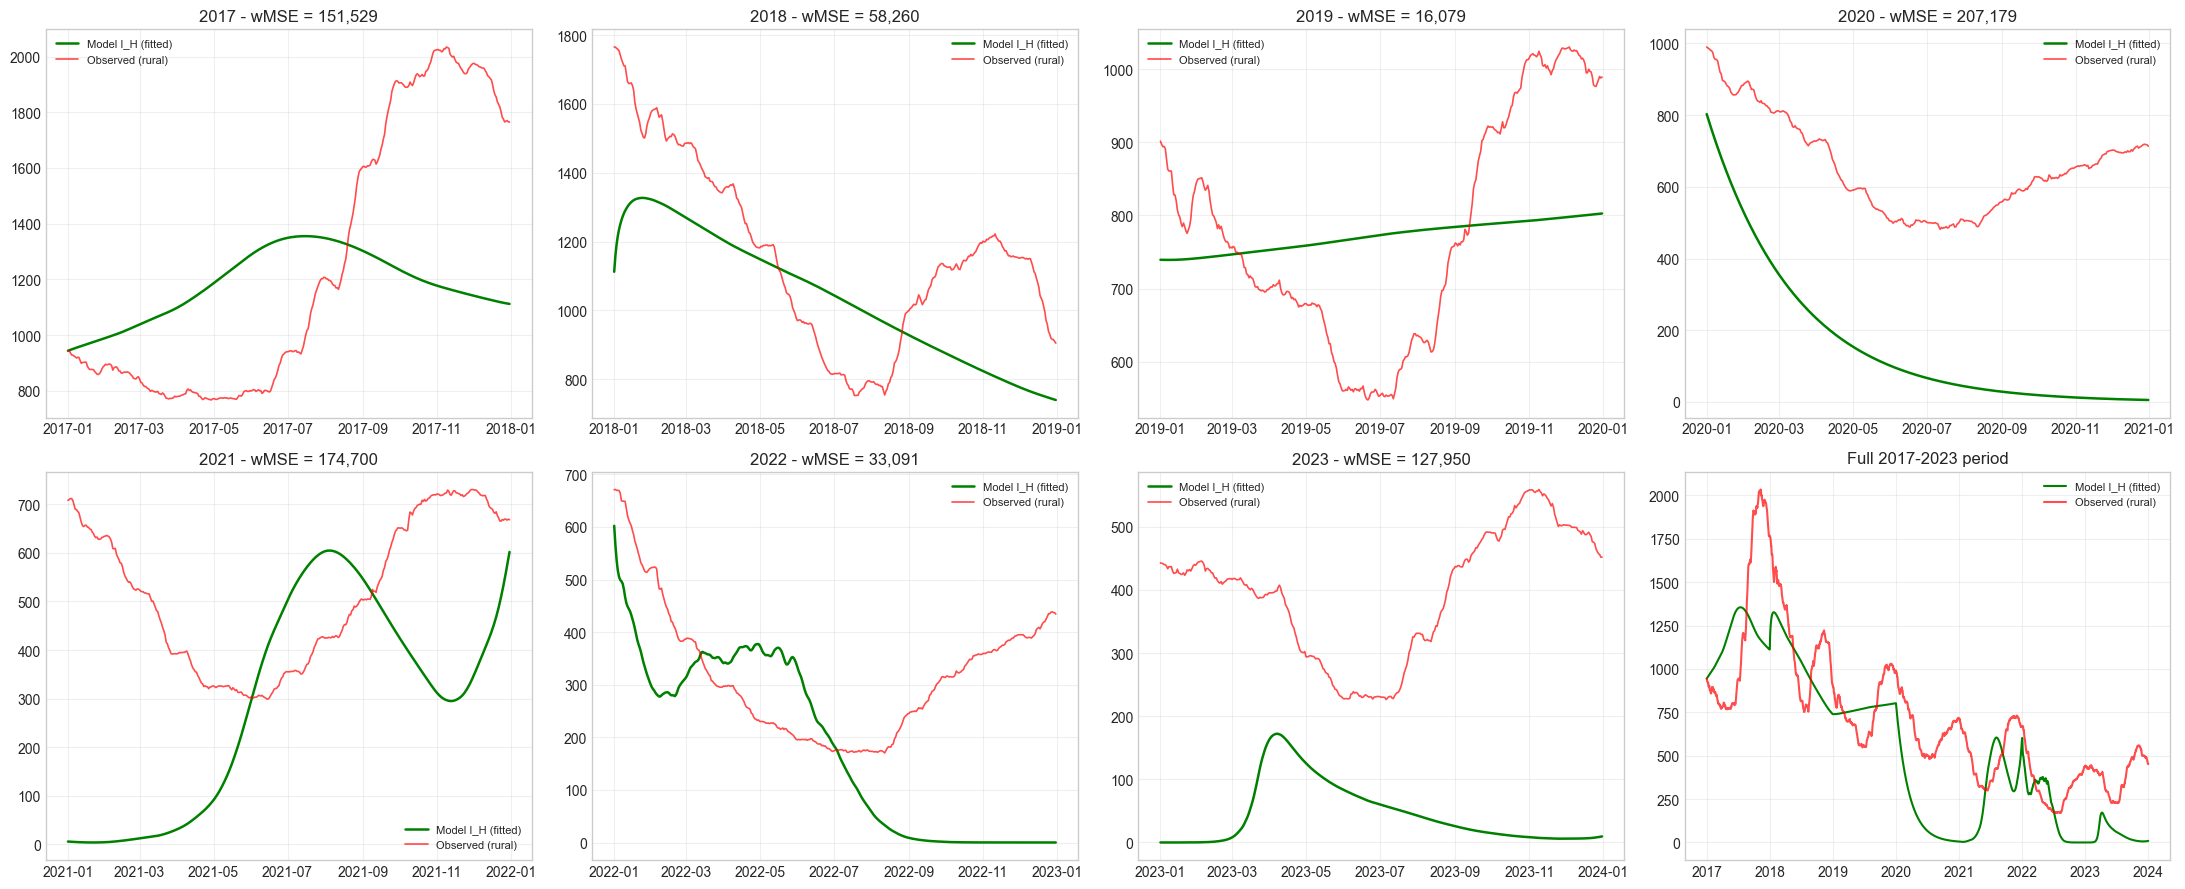

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.ravel()
for i, y in enumerate(YEARS):
    ax = axes[i]
    dates, IH = trajectories[y]
    obs = observed_for_year(y)
    ax.plot(pd.to_datetime(dates), IH, 'g-', linewidth=1.8, label='Model I_H (fitted)')
    ax.plot(obs['date'], obs['active_total'], 'r-', alpha=0.7, linewidth=1.2, label='Observed (rural)')
    ax.set_title(f'{y} - wMSE = {results[str(y)]["weighted_mse"]:,.0f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

ax = axes[-1]
all_dates, all_IH = [], []
for y in YEARS:
    d, ih = trajectories[y]
    all_dates.extend(d)
    all_IH.extend(ih)
ax.plot(pd.to_datetime(all_dates), all_IH, 'g-', linewidth=1.5, label='Model I_H (fitted)')
ax.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', alpha=0.7, label='Observed (rural)')
ax.set_title('Full 2017-2023 period')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 8 - Fitted parameter evolution across years

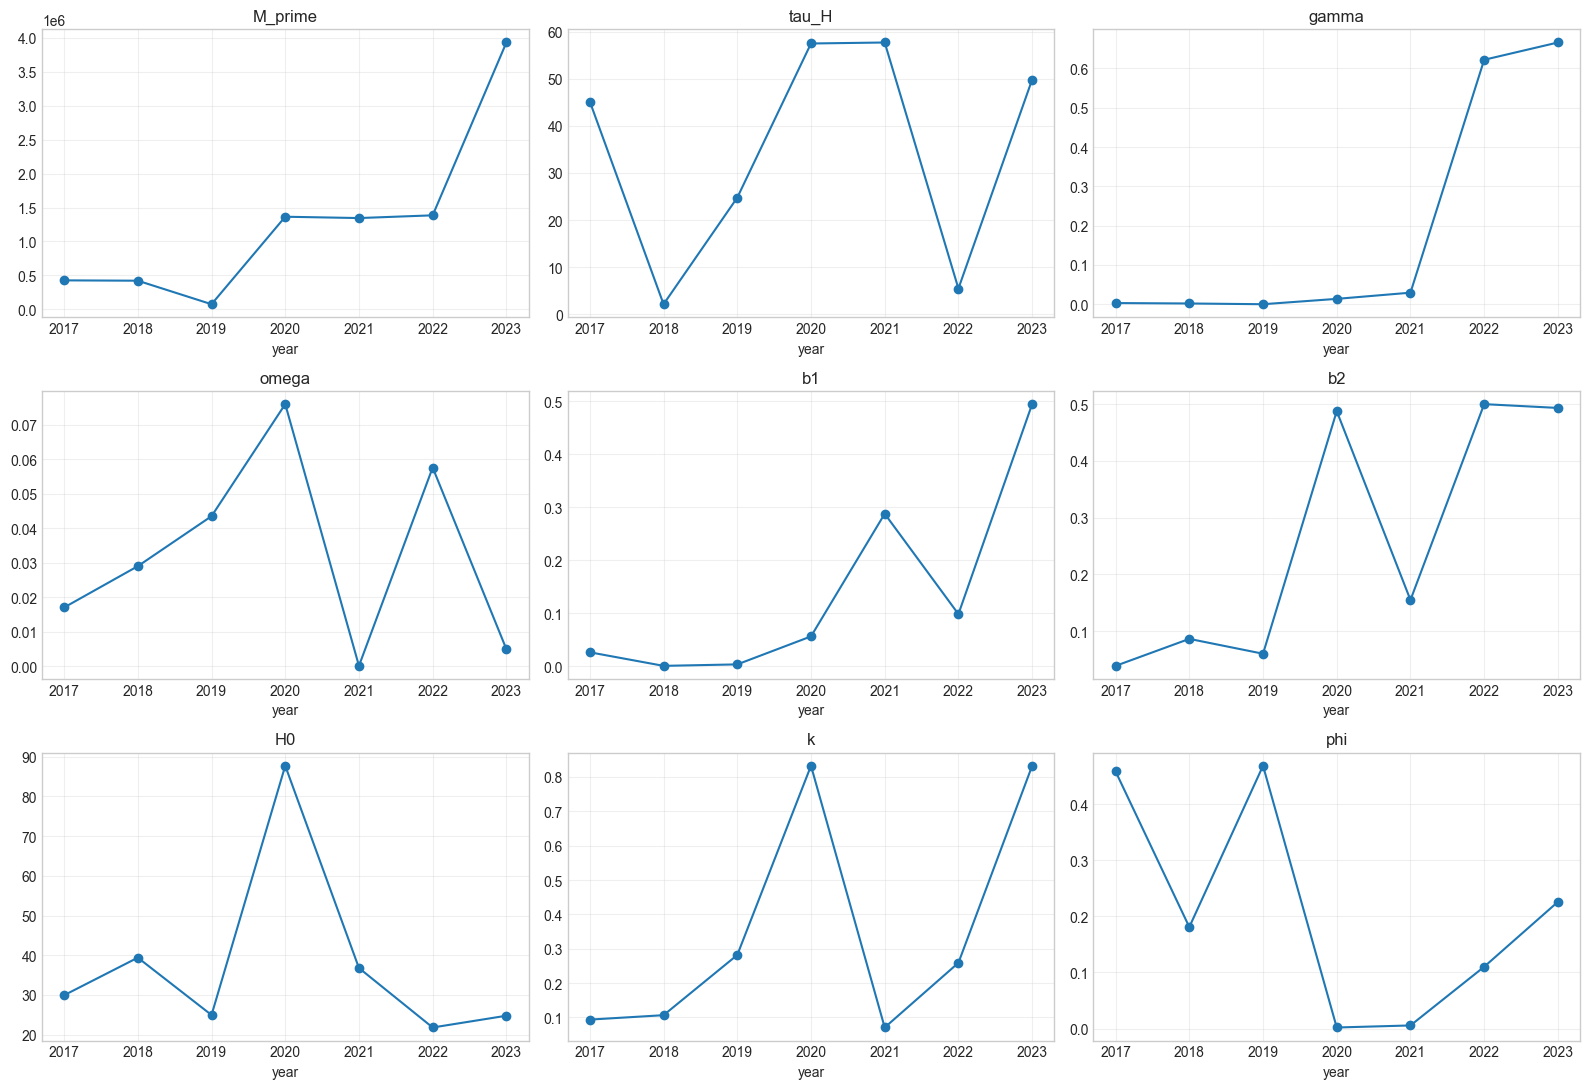

In [17]:
params_of_interest = ['M_prime', 'tau_H', 'gamma', 'omega', 'b1', 'b2', 'H0', 'k', 'phi']
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.ravel()
for ax, name in zip(axes, params_of_interest):
    vals = [results[str(y)]['params'][name] for y in YEARS]
    ax.plot(YEARS, vals, 'o-', linewidth=1.5)
    ax.set_title(name)
    ax.set_xlabel('year')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Notes

- Results are saved to `lmfit_results.json`. To resume a previous run (load the
  saved file instead of re-fitting), call `run_yearly_fit(resume=True, ...)`.
- `success=False` in the per-topic summary just means the DE evaluation budget
  (`max_nfev`) was reached before convergence; the reported parameters are still
  the best found within that budget.
- `chisqr` follows the lmfit convention for a scalar objective (chisqr = wMSE^2);
  the `wMSE` column shows sqrt(chisqr), i.e. the weighted MSE at that stage.
- The weighted MSE uses exponential decay within each year, so the first months of
  each year dominate the fit.